# DX 704 Week 4 Project

This week's project will test the learning speed of linear contextual bandits compared to unoptimized approaches.
You will start with building a preference data set for evaluation, and then implement different variations of LinUCB and visualize how fast they learn the preferences.


The full project description, a template notebook and supporting code are available on GitHub: [Project 4 Materials](https://github.com/bu-cds-dx704/dx704-project-04).


## Example Code

You may find it helpful to refer to these GitHub repositories of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples
* https://github.com/bu-cds-omds/dx603-examples
* https://github.com/bu-cds-omds/dx704-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Part 1: Collect Rating Data

The file "recipes.tsv" in this repository has information about 100 recipes.
Make a new file "ratings.tsv" with two columns, recipe_slug (from recipes.tsv) and rating.
Populate the rating column with values between 0 and 1 where 0 is the worst and 1 is the best.
You can assign these ratings however you want within that range, but try to make it reflect a consistent set of preferences.
These could be your preferences, or a persona of your choosing (e.g. chocolate lover, bacon-obsessed, or sweet tooth).
Make sure that there are at least 10 ratings of zero and at least 10 ratings of one.


Hint: You may find it more convenient to assign raw ratings from 1 to 5 and then remap them as follows.

`ratings["rating"] = (ratings["rating_raw"] - 1) * 0.25`

In [1]:
import numpy as np
import pandas as pd

recipes = pd.read_csv("recipes.tsv", sep="\t")

raw_ratings = {
    "falafel": 3,
    "spamburger": 4,
    "bacon-fried-rice": 5,
    "chicken-fingers": 3,
    "apple-crisp": 1,
    "cranberry-apple-crisp": 1,
    "bacon-chocolate-chip-cookies": 3,
    "sujebi": 4,
    "pasta-primavera": 2,
    "ramen": 5,
    "brownies": 1,
    "bacon-wrapped-scallops": 5,
    "bacon-egg-muffins": 4,
    "breakfast-burritos": 5,
    "bolognese-sauce": 4,
    "croissants": 2,
    "bacon-souffle": 4,
    "souffle": 3,
    "chocolate-souffle": 1,
    "butter-croissants": 2,
    "pickled-green-beans": 3,
    "fried-oysters": 4,
    "peanut-butter-brownies": 1,
    "almond-chip-cookies": 1,
    "guacamole": 4,
    "brioche-bread": 2,
    "brioche-bread-with-chocolate": 1,
    "asparagus-quiche": 2,
    "asparagus-burger": 2,
    "ma-la-chicken": 5,
    "cold-noodles-with-tomatoes": 3,
    "tamales": 4,
    "enchiladas": 5,
    "tacos": 5,
    "burritos": 4,
    "peanut-butter-cupcakes": 1,
    "pickled-asparagus": 2,
    "chocolate-peanut-butter-cake": 1,
    "udon": 3,
    "vegetable-lasagna": 2,
    "maple-bacon-donuts": 2,
    "maple-bacon-pancakes": 3,
    "spinach-and-ricotta-stuffed-shells": 2,
    "quesadillas": 5,
    "pico-de-gallo": 4,
    "nachos": 5,
    "cold-soba-noodles-with-tomato-and-cucumber": 2,
    "fajitas": 5,
    "loaded-nachos": 5,
    "lasagna": 4,
    "chicken-nuggets": 3,
    "pain-au-chocolat": 1,
    "nacho-dip": 4,
    "nacho-salad": 4,
    "nacho-casserole": 4,
    "nacho-fries": 5,
    "tempura-udon": 3,
    "peach-crisp": 1,
    "apple-pie": 1,
    "blueberry-crisp": 1,
    "berry-crumble": 1,
    "strawberry-rhubarb-crisp": 1,
    "peach-cobbler": 1,
    "cranberry-sauce": 2,
    "cherry-cobbler": 1,
    "apple-crumble": 1,
    "chocolate-croissants": 1,
    "french-toast": 2,
    "chocolate-babka": 1,
    "cinnamon-babka": 1,
    "blueberry-crumble": 1,
    "spam-musubi": 4,
    "taco-salad": 4,
    "chiles-rellenos": 5,
    "almond-croissants": 1,
    "cranberry-relish": 2,
    "ma-la-beef": 5,
    "chocolate-cake": 1,
    "spinach-quiche": 2,
    "mushroom-quiche": 2,
    "quiche-lorraine": 4,
    "croissant-aux-amandes": 1,
    "danishes": 2,
    "spinach-and-feta-quiche": 2,
    "cold-sesame-noodles": 3,
    "soba-noodle-salad-with-peanut-dressing": 3,
    "dan-dan-noodles": 5,
    "vanilla-souffle": 1,
    "bacon-wrapped-dates": 4,
    "cherry-pie": 1,
    "berry-crisp": 1,
    "bacon-and-egg-breakfast-sandwich": 5,
    "bacon-wrapped-shrimp-skewers": 5,
    "bacon-wrapped-chicken": 5,
    "bacon-wrapped-asparagus": 4,
    "bacon-mac-and-cheese": 5,
    "chicken-alfredo-lasagna": 4,
    "classic-beef-lasagna": 4,
    "vegetarian-mushroom-lasagna": 2,
    "spinach-and-ricotta-lasagna": 2,
}

assert set(raw_ratings) == set(recipes["recipe_slug"])

ratings = recipes[["recipe_slug"]].copy()
ratings["rating_raw"] = ratings["recipe_slug"].map(raw_ratings)
ratings["rating"] = (ratings["rating_raw"] - 1) * 0.25
ratings = ratings[["recipe_slug", "rating"]]

ratings.to_csv("ratings.tsv", sep="\t", index=False)

print("ratings of zero:", (ratings["rating"] == 0).sum())
print("ratings of one:", (ratings["rating"] == 1).sum())
ratings["rating"].value_counts().sort_index()


ratings of zero: 28
ratings of one: 19


rating
0.00    28
0.25    20
0.50    12
0.75    21
1.00    19
Name: count, dtype: int64

Submit "ratings.tsv" in Gradescope.

## Part 2: Construct Model Input

Use your file "ratings.tsv" combined with "recipe-tags.tsv" to create a new file "features.tsv" with a column recipe_slug, a column bias which is hard-coded to one, and a column for each tag that appears in "recipe-tags.tsv".
The tag column in this file should be a 0-1 encoding of the recipe tags for each recipe.
[Pandas reshaping function methods](https://pandas.pydata.org/docs/user_guide/reshaping.html) may be helpful.

The bias column will make later LinUCB calculations easier since it will just be another dimension.

Hint: For later modeling steps, it will be important to have the feature data (inputs) and the rating data (target outputs) in the same order.
It is highly recommended to make sure that "features.tsv" and "ratings.tsv" have the recipe slugs in the same order.

In [2]:
recipe_tags = pd.read_csv("recipe-tags.tsv", sep="\t")

tag_matrix = pd.crosstab(recipe_tags["recipe_slug"], recipe_tags["recipe_tag"]).clip(upper=1)

# keep the recipes in the same order as ratings.tsv
features = ratings[["recipe_slug"]].copy()
features["bias"] = 1
features = features.join(tag_matrix, on="recipe_slug")

assert (features["recipe_slug"] == ratings["recipe_slug"]).all()
assert features.drop(columns="recipe_slug").notna().all().all()

features.to_csv("features.tsv", sep="\t", index=False)

features.shape


(100, 298)

Submit "features.tsv" in Gradescope.

## Part 3: Linear Preference Model

Use your feature and rating files to build a ridge regression model with ridge regression's regularization parameter $\alpha$ set to 1.


Hint: If you are using scikit-learn modeling classes, you should use `fit_intercept=False` since that intercept value will be redundant with the bias coefficient.

Hint: The estimate component of the bounds should match the previous estimate, so you should be able to just focus on the variance component of the bounds now.

In [3]:
from sklearn.linear_model import Ridge

feature_cols = features.columns.drop("recipe_slug")
X = features[feature_cols].to_numpy(dtype=float)
y = ratings["rating"].to_numpy()

model = Ridge(alpha=1, fit_intercept=False)
model.fit(X, y)

A = X.T @ X + np.eye(X.shape[1])
theta = np.linalg.solve(A, X.T @ y)
assert np.allclose(model.coef_, theta)

print("training RMSE:", np.sqrt(np.mean((model.predict(X) - y) ** 2)))


training RMSE: 0.032565194635747294


Save the coefficients of this model in a file "model.tsv" with columns "recipe_tag" and "coefficient".
Do not add anything for the `intercept_` attribute of a scikit-learn model; this will be covered by the coefficient for the bias column added in part 2.

In [4]:
coefficients = pd.DataFrame({"recipe_tag": feature_cols, "coefficient": model.coef_})
coefficients.to_csv("model.tsv", sep="\t", index=False)

coefficients.sort_values("coefficient", ascending=False)


,recipe_tag,coefficient
0,bias,0.429544
10,bacon,0.254399
253,spicy,0.155817
170,mexican,0.150299
223,salsa,0.118699
...,...,...
264,sweet,-0.075834
267,sweettreat,-0.076996
2,almond,-0.098247
292,vegetarian,-0.100608


Submit "model.tsv" in Gradescope.

## Part 4: Recipe Estimates

Use the recipe model to estimate the score of every recipe.
Save these estimates to a file "estimates.tsv" with columns recipe_slug and score_estimate.

In [5]:
estimates = pd.DataFrame({
    "recipe_slug": features["recipe_slug"],
    "score_estimate": model.predict(X),
})
estimates.to_csv("estimates.tsv", sep="\t", index=False)

estimates.sort_values("score_estimate", ascending=False)


,recipe_slug,score_estimate
29,ma-la-chicken,0.999003
43,quesadillas,0.996420
45,nachos,0.989021
33,tacos,0.986826
55,nacho-fries,0.985491
...,...,...
35,peanut-butter-cupcakes,-0.001668
90,berry-crisp,-0.001876
61,strawberry-rhubarb-crisp,-0.004514
5,cranberry-apple-crisp,-0.009836


Submit "estimates.tsv" in Gradescope.

## Part 5: LinUCB Bounds

Calculate the upper bounds of LinUCB using data corresponding to trying every recipe once and receiving the rating in "ratings.tsv" as the reward.
Keep the ridge regression regularization parameter at 1, and set LinUCB's $\alpha$ parameter to 2.
Save these upper bounds to a file "bounds.tsv" with columns recipe_slug and score_bound.

In [6]:
LINUCB_ALPHA = 2

A_inv = np.linalg.inv(A)
widths = np.sqrt(np.einsum("ij,jk,ik->i", X, A_inv, X))

bounds = pd.DataFrame({
    "recipe_slug": features["recipe_slug"],
    "score_bound": estimates["score_estimate"] + LINUCB_ALPHA * widths,
})
bounds.to_csv("bounds.tsv", sep="\t", index=False)

bounds.sort_values("score_bound", ascending=False)


,recipe_slug,score_bound
29,ma-la-chicken,2.876703
9,ramen,2.872934
43,quesadillas,2.864986
86,dan-dan-noodles,2.858999
2,bacon-fried-rice,2.851549
...,...,...
66,chocolate-croissants,1.650986
59,blueberry-crisp,1.593005
70,blueberry-crumble,1.587756
18,chocolate-souffle,1.576718


Submit "bounds.tsv" in Gradescope.

## Part 6: Make Online Recommendations

Implement LinUCB to make 100 recommendations starting with no data and using the same parameters as in part 5.
One recommendation should be made at a time and you can break ties arbitrarily.
After each recommendation, use the rating from part 1 as the reward to update the LinUCB data.
Record the recommendations made in a file "recommendations.tsv" with columns "recipe_slug", "score_bound", and "reward".
The rows in this file should be in the same order as the recommendations were made.

Hint: do not remove recipes after each recommendation.
Repeating recommendations is expected.

In [7]:
def linucb(X, rewards, num_steps, alpha=LINUCB_ALPHA, ridge=1):
    d = X.shape[1]
    A = ridge * np.eye(d)
    b = np.zeros(d)

    chosen = []
    chosen_bounds = []
    chosen_rewards = []

    for _ in range(num_steps):
        A_inv = np.linalg.inv(A)
        theta = A_inv @ b
        bound = X @ theta + alpha * np.sqrt(np.einsum("ij,jk,ik->i", X, A_inv, X))

        i = int(np.argmax(bound))
        reward = rewards[i]

        A += np.outer(X[i], X[i])
        b += reward * X[i]

        chosen.append(i)
        chosen_bounds.append(bound[i])
        chosen_rewards.append(reward)

    return np.array(chosen), np.array(chosen_bounds), np.array(chosen_rewards)


NUM_RECOMMENDATIONS = 100

chosen, chosen_bounds, chosen_rewards = linucb(X, y, NUM_RECOMMENDATIONS)

recommendations = pd.DataFrame({
    "recipe_slug": features["recipe_slug"].to_numpy()[chosen],
    "score_bound": chosen_bounds,
    "reward": chosen_rewards,
})
recommendations.to_csv("recommendations.tsv", sep="\t", index=False)

print("distinct recipes recommended:", recommendations["recipe_slug"].nunique())
print("total reward:", recommendations["reward"].sum())
recommendations


distinct recipes recommended: 95
total reward: 50.25


,recipe_slug,score_bound,reward
0,apple-crumble,7.483315,0.0
1,ma-la-chicken,7.192589,1.0
2,quesadillas,7.256360,1.0
3,ramen,7.230947,1.0
4,bacon-fried-rice,7.044615,1.0
...,...,...,...
95,ma-la-chicken,2.876566,1.0
96,ramen,2.873696,1.0
97,quesadillas,2.864760,1.0
98,dan-dan-noodles,2.857605,1.0


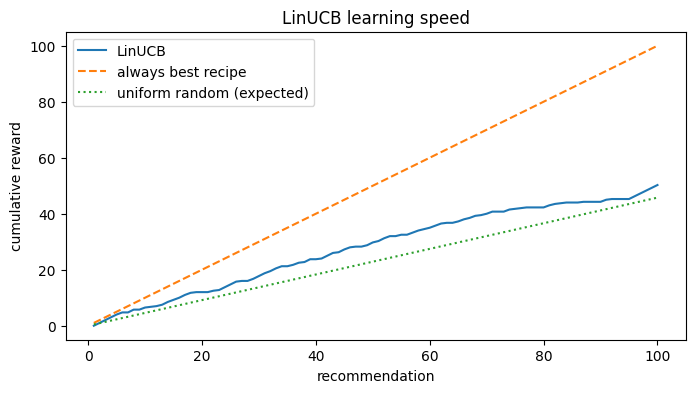

In [8]:
import matplotlib.pyplot as plt

steps = np.arange(1, NUM_RECOMMENDATIONS + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(steps, np.cumsum(chosen_rewards), label="LinUCB")
ax.plot(steps, steps * y.max(), linestyle="--", label="always best recipe")
ax.plot(steps, steps * y.mean(), linestyle=":", label="uniform random (expected)")
ax.set_xlabel("recommendation")
ax.set_ylabel("cumulative reward")
ax.set_title("LinUCB learning speed")
ax.legend()
plt.show()

Submit "recommendations.tsv" in Gradescope.

## Part 7: Acknowledgments

Make a file "acknowledgments.txt" documenting any outside sources or help on this project.
If you discussed this assignment with anyone, please acknowledge them here.
If you used any libraries not mentioned in this module's content, please list them with a brief explanation what you used them for.
If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the generative AI policy.
If no acknowledgements are appropriate, just write none in the file.


Submit "acknowledgments.txt" in Gradescope.

## Part 8: Code

Please submit a Jupyter notebook that can reproduce all your calculations and recreate the previously submitted files.


Submit "project.ipynb" in Gradescope.